In [151]:
import numpy as np
import pandas as pd
import re

df = pd.read_csv(r'C:\Users\A.R.I\Desktop\Data_Analysis\matchs_grok.csv')

In [152]:
df_grok_all = df[(df["grok_in_a"]) | (df["grok_in_b"])].copy()


df_grok_all["opponent"] = np.where(df_grok_all["grok_in_a"],
                                   df_grok_all["model_b"],
                                   df_grok_all["model_a"])


df_grok_all["is_grok_win"] = (
    ((df_grok_all["winner"] == "model_a") & df_grok_all["grok_in_a"]) |
    ((df_grok_all["winner"] == "model_b") & df_grok_all["grok_in_b"])
)

df_grok_all["is_grok_tie"] = (df_grok_all["winner"] == "tie")
df_grok_all["is_both_bad"] = (df_grok_all["winner"] == "both_bad")


df_grok_all["is_grok_loss"] = (
    (~df_grok_all["is_grok_win"] & ~df_grok_all["is_grok_tie"]) |
    df_grok_all["is_both_bad"]
)

In [153]:
opp_stats_all = (
    df_grok_all
      .groupby("opponent")
      .agg(matches=("id", "count"),
           wins=("is_grok_win", "sum"),
           ties=("is_grok_tie", "sum"),
           losses=("is_grok_loss", "sum"))
      .reset_index()
)


min_matches = 20
big_opponents = opp_stats_all[opp_stats_all["matches"] >= min_matches]["opponent"]

print("Number of opponents with ≥20 matches:", len(big_opponents))
print(opp_stats_all[opp_stats_all["opponent"].isin(big_opponents)])

Number of opponents with ≥20 matches: 49
                                        opponent  matches  wins  ties  losses
0            amazon-nova-experimental-chat-05-14       57    28    11      18
1                           amazon.nova-pro-v1:0      109    67    19      23
2                     chatgpt-4o-latest-20250326      155    54    30      71
3                      claude-3-5-haiku-20241022      138    83    15      40
4                     claude-3-5-sonnet-20241022      151    88    18      45
5                     claude-3-7-sonnet-20250219      144    88    13      43
6        claude-3-7-sonnet-20250219-thinking-32k      121    74    18      29
7                         claude-opus-4-20250514      210   103    30      77
8            claude-opus-4-20250514-thinking-16k      107    59    15      33
9                       claude-sonnet-4-20250514      145    82    19      44
10         claude-sonnet-4-20250514-thinking-32k       88    51     9      28
11                     

In [154]:
grok_losses_20 = df_grok_all[
    (df_grok_all["opponent"].isin(big_opponents)) &
    (df_grok_all["is_grok_loss"])
].copy()

print("Total Grok losses vs opponents with ≥20 matches:", len(grok_losses_20))

Total Grok losses vs opponents with ≥20 matches: 1873


In [166]:
def _is_nan(x):
    return x is None or (isinstance(x, float) and x != x)


# ------------------------------------------------------
#Question Detection 
# ------------------------------------------------------
def has_question_at_end(text, window=3):
    if _is_nan(text):
        return False
    
    lines = [l.strip() for l in str(text).split("\n") if l.strip()]

    # Take last N lines
    tail = "\n".join(lines[-window:]).lower()

    # must contain ?
    if "?" not in tail:
        return False

    # must contain English letters to avoid noise
    if not re.search(r"[a-z]", tail):
        return False

    
    question_patterns = [
        r"\?$",                           
        r"\bdo you\b",
        r"\bwould you\b",
        r"\bshould I\b",
        r"\bcan I\b",
        r"\bcan you\b",
        r"\bwhat else\b",
        r"\banything else\b",
        r"\bwant me to\b",
    ]

    return any(re.search(p, tail) for p in question_patterns)



# ------------------------------------------------------
# Conclusion Detection 
# ------------------------------------------------------
def has_conclusion(text):
    if _is_nan(text):
        return False

    t = str(text).lower().strip()

    # Extract last paragraph 
    paragraphs = [p.strip() for p in t.split("\n") if p.strip()]
    
    if not paragraphs:
        return False

    last_para = paragraphs[-1]

    patterns = [
        r"\bin conclusion\b",
        r"\bto conclude\b",
        r"\bto summarize\b",
        r"\bin summary\b",
        r"\bultimately\b",
        r"\bin the end\b",
        r"\bto wrap up\b",
        r"\btherefore\b",
        r"\boverall\b",   
        r"^so[, ]",       
    ]

    # Allow detection only if the phrase appears IN THE LAST PARAGRAPH
    return any(re.search(p, last_para) for p in patterns)



# ------------------------------------------------------
# Next-step logic 
# ------------------------------------------------------
def has_next_steps(text, para_window=3):
    if _is_nan(text):
        return False
    
    t = str(text).strip().lower()

    # 1) split into paragraphs ---
    paragraphs = [p.strip() for p in t.split("\n") if p.strip()]
    if not paragraphs:
        return False

    # take only the last few paragraphs
    tail = "\n".join(paragraphs[-para_window:])

    # 2) must contain 'you' or 'your' (true user-targeted guidance) ---
    if not re.search(r"\b(you|your)\b", tail):
        return False

    #  3) real next-step phrases (imperative style) ---
    patterns = [
        r"\byou can\b",
        r"\byou should\b",
        r"\bwhat you can do\b",
        r"\bhere(?:'s| is) what you\b",
        r"\bnext[, ]?\b",                     
        r"\brecommend( you)?\b",
        r"\bconsider\b",
        r"\btry\b",
        r"\bto do this, you\b",
        r"\bthe next step\b",
    ]

    # must match BOTH:
    #   guidance pattern + user pronoun
    return any(re.search(p, tail) for p in patterns)



# ------------------------------------------------------
# Interaction invitation 
# ------------------------------------------------------
def has_interaction_prompt(text):
    if _is_nan(text): 
        return False
    t = str(text).lower()

    patterns = [
        r"\blet me know\b",
        r"\bfeel free to ask\b",
        r"\bif you'd like\b",
        r"\bif you want\b",
        r"\bwould you like\b",
        r"\bany other questions\b",
        r"\banything else\b",
    ]
    return any(re.search(p, t) for p in patterns)


# ------------------------------------------------------
# Master Feature Extractor
# ------------------------------------------------------
def compute_interactive_features(text):
    return {
        "has_question": has_question_at_end(text),   
        "has_conclusion": has_conclusion(text),
        "has_next_steps": has_next_steps(text),
        "has_interaction_prompt": has_interaction_prompt(text),
    }



# ------------------------------------------------------
# Apply on df
# ------------------------------------------------------
def extract_interactive_features(df_losses):
    df = df_losses.copy()

    df["grok_response"] = df.apply(
        lambda row: row["response_a"] if row["grok_in_a"] else row["response_b"],
        axis=1
    )
    df["opp_response"] = df.apply(
        lambda row: row["response_b"] if row["grok_in_a"] else row["response_a"],
        axis=1
    )

    # Grok
    grok_feats = df["grok_response"].apply(compute_interactive_features)
    df["grok_has_question"] = grok_feats.apply(lambda x: x["has_question"])
    df["grok_has_conclusion"] = grok_feats.apply(lambda x: x["has_conclusion"])
    df["grok_has_next_steps"] = grok_feats.apply(lambda x: x["has_next_steps"])
    df["grok_has_interaction_prompt"] = grok_feats.apply(lambda x: x["has_interaction_prompt"])

    # Opponent
    opp_feats = df["opp_response"].apply(compute_interactive_features)
    df["opp_has_question"] = opp_feats.apply(lambda x: x["has_question"])
    df["opp_has_conclusion"] = opp_feats.apply(lambda x: x["has_conclusion"])
    df["opp_has_next_steps"] = opp_feats.apply(lambda x: x["has_next_steps"])
    df["opp_has_interaction_prompt"] = opp_feats.apply(lambda x: x["has_interaction_prompt"])

    df["grok_interaction_score"] = (
        df["grok_has_question"].astype(int)
        + df["grok_has_conclusion"].astype(int)
        + df["grok_has_next_steps"].astype(int)
        + df["grok_has_interaction_prompt"].astype(int)
    )

    df["opp_interaction_score"] = (
        df["opp_has_question"].astype(int)
        + df["opp_has_conclusion"].astype(int)
        + df["opp_has_next_steps"].astype(int)
        + df["opp_has_interaction_prompt"].astype(int)
    )

    df["interaction_gap"] = df["opp_interaction_score"] - df["grok_interaction_score"]

    return df


In [156]:
interactive_all_losses = extract_interactive_features(grok_losses_20)
total_losses = len(interactive_all_losses)

summary_global_20 = pd.DataFrame([{
    "total_losses": total_losses,
    "grok_has_question_%":      100 * interactive_all_losses["grok_has_question"].mean(),
    "opp_has_question_%":       100 * interactive_all_losses["opp_has_question"].mean(),
    "grok_has_conclusion_%":    100 * interactive_all_losses["grok_has_conclusion"].mean(),
    "opp_has_conclusion_%":     100 * interactive_all_losses["opp_has_conclusion"].mean(),
    "grok_has_next_steps_%":    100 * interactive_all_losses["grok_has_next_steps"].mean(),
    "opp_has_next_steps_%":     100 * interactive_all_losses["opp_has_next_steps"].mean(),
    "grok_has_inter_prompt_%":  100 * interactive_all_losses["grok_has_interaction_prompt"].mean(),
    "opp_has_inter_prompt_%":   100 * interactive_all_losses["opp_has_interaction_prompt"].mean(),
    "avg_grok_interaction_score": interactive_all_losses["grok_interaction_score"].mean(),
    "avg_opp_interaction_score":  interactive_all_losses["opp_interaction_score"].mean(),
    "avg_interaction_gap":        interactive_all_losses["interaction_gap"].mean(),
}]).round(2)

summary_global_20.T

,0
total_losses,1873.00
grok_has_question_%,2.56
opp_has_question_%,10.89
grok_has_conclusion_%,3.15
opp_has_conclusion_%,3.74
grok_has_next_steps_%,12.17
opp_has_next_steps_%,6.99
grok_has_inter_prompt_%,16.60
opp_has_inter_prompt_%,14.58
avg_grok_interaction_score,0.34


In [157]:
by_opponent_20 = (
    interactive_all_losses
      .groupby("opponent")
      .agg(
          matches=("id", "count"),
          avg_grok_score=("grok_interaction_score", "mean"),
          avg_opp_score=("opp_interaction_score", "mean"),
          avg_gap=("interaction_gap", "mean"),
          grok_more_interactive_pct=("interaction_gap", lambda s: 100 * (s < 0).mean()),
          opp_more_interactive_pct=("interaction_gap", lambda s: 100 * (s > 0).mean()),
      )
      .round(2)
      .sort_values("matches", ascending=False)
)

by_opponent_20

,matches,avg_grok_score,avg_opp_score,avg_gap,grok_more_interactive_pct,opp_more_interactive_pct
opponent,,,,,,
gemini-2.5-pro,95,0.33,0.24,-0.08,17.89,9.47
o3-2025-04-16,77,0.23,0.22,-0.01,12.99,11.69
claude-opus-4-20250514,77,0.26,0.17,-0.09,16.88,10.39
chatgpt-4o-latest-20250326,71,0.27,0.66,0.39,4.23,33.80
qwen3-235b-a22b-no-thinking,68,0.34,0.57,0.24,10.29,27.94
deepseek-r1-0528,64,0.31,0.14,-0.17,17.19,4.69
gemini-2.5-flash,62,0.35,0.26,-0.10,17.74,11.29
mistral-medium-2505,61,0.33,0.72,0.39,13.11,32.79
gemma-3-27b-it,55,0.29,0.25,-0.04,16.36,14.55


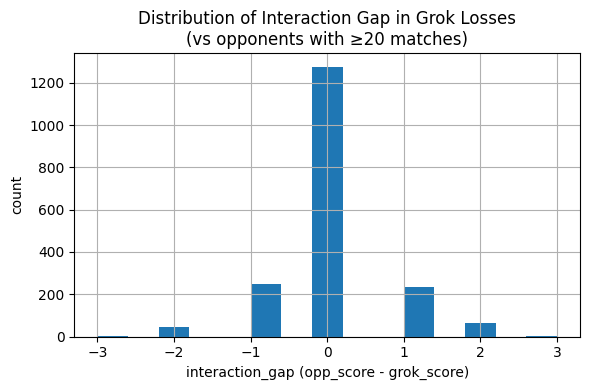

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
interactive_all_losses["interaction_gap"].hist(bins=15)
plt.title("Distribution of Interaction Gap in Grok Losses\n(vs opponents with ≥20 matches)")
plt.xlabel("interaction_gap (opp_score - grok_score)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [159]:
def inspect_samples(df, feature_col, speaker="opp", n=5):
    """
    df: interactive_all_losses
    feature_col: e.g., "opp_has_question"
    speaker: "opp" or "grok"
    """
    col = f"{speaker}_response"
    subset = df[df[feature_col]]

    if subset.empty:
        print(f"No rows found where {feature_col} = True")
        return

    samples = subset.sample(min(n, len(subset)), random_state=42)

    for i, row in samples.iterrows():
        print("="*120)
        print(f"SAMPLE INDEX: {i}")
        print(f"Opponent model: {row['opponent']}")
        print(f"Feature flagged → {feature_col}")
        
        print("\n--- USER PROMPT ----------------------------------------------------")
        print(row["user_prompt"])

        print(f"\n--- FULL {speaker.upper()} RESPONSE ------------------------------------")
        print(row[col])   
        print("="*120, "\n")

In [160]:
inspect_samples(interactive_all_losses, "opp_has_conclusion", speaker="opp", n=3)

SAMPLE INDEX: 2050
Opponent model: claude-3-5-haiku-20241022
Feature flagged → opp_has_conclusion

--- USER PROMPT ----------------------------------------------------
What is the probability of rolling six sixes on a six-sided dice


--- FULL OPP RESPONSE ------------------------------------
Let me solve this step by step:

1) To roll a six on a single die, the probability is 1/6

2) To roll six sixes in a row, we need to multiply the individual probabilities:
   (1/6) * (1/6) * (1/6) * (1/6) * (1/6) * (1/6)

3) This can be calculated as (1/6)^6

4) Let's compute this:
   (1/6)^6 = 1/46,656

5) As a decimal, this is approximately 0.0000214 or about 0.00214%

So the probability of rolling six sixes in a row on a six-sided die is 1 in 46,656, which is extremely low. This means it's a very rare event that would happen very infrequently if you were to roll six dice simultaneously or in sequence.

SAMPLE INDEX: 156
Opponent model: llama-4-maverick-03-26-experimental
Feature flagged → opp_h

In [161]:
inspect_samples(interactive_all_losses, "grok_has_question", speaker="grok", n=3)

SAMPLE INDEX: 1906
Opponent model: minimax-m1
Feature flagged → grok_has_question

--- USER PROMPT ----------------------------------------------------
Please tell me a 'shower thought'

--- FULL GROK RESPONSE ------------------------------------
Here's a fun shower thought for you:

"If you think about it, a staircase is just one long diagonal step that we’ve decided to break into smaller, more manageable pieces—yet we still trip over it." 

What do you think? Want another, or got a shower thought of your own to share? 🚿💭

SAMPLE INDEX: 4023
Opponent model: gemini-2.5-flash-lite-preview-06-17-thinking
Feature flagged → grok_has_question

--- USER PROMPT ----------------------------------------------------
speaking of privacy, isn't it scary that keyoards can actually see and store what ever we type underthe hoodl

--- FULL GROK RESPONSE ------------------------------------
Yeah, the idea of keyboards—or any input device—potentially "seeing" and storing what we type can definitely feel

In [165]:
inspect_samples(interactive_all_losses, "opp_has_interaction_prompt", n=5)

SAMPLE INDEX: 559
Opponent model: gemini-2.5-flash
Feature flagged → opp_has_interaction_prompt

--- USER PROMPT ----------------------------------------------------
In Singapore’s humidity and temperature is it better to store bread in the fridge?

--- FULL OPP RESPONSE ------------------------------------
In Singapore's high humidity and warm temperatures, **it is generally better to store bread in the fridge if you want to prevent mold growth and extend its shelf life beyond 1-2 days.**

However, there's a significant trade-off: **bread stales much faster in the fridge.** This is due to a process called "starch retrogradation," where the starch molecules re-crystallize, making the bread hard, dry, and crumbly.

Here's a breakdown of the storage options in Singapore's climate:

1.  **Room Temperature (Countertop/Pantry):**
    *   **Pros:** Best texture for immediate consumption.
    *   **Cons:** **Very short shelf life.** Due to high humidity and warmth, mold can appear within 1-2 

In [163]:
inspect_samples(interactive_all_losses, "grok_has_next_steps", speaker="grok", n=3)

SAMPLE INDEX: 4989
Opponent model: gemini-2.5-flash-preview-04-17
Feature flagged → grok_has_next_steps

--- USER PROMPT ----------------------------------------------------
What is the best approach for me if i want the simplest possible secret management tool. No need in extra features, need self hosted, lightweight, with embedded db like sqlite and simple http api. Dont want anything else, hashicorp, infisical dont suit those requirements

--- FULL GROK RESPONSE ------------------------------------
If you're looking for the simplest possible self-hosted secret management tool with a lightweight design, an embedded database like SQLite, and a basic HTTP API, your best approach is to either use an existing minimalistic open-source solution or build your own tailored tool. Since you explicitly want to avoid feature-heavy solutions like HashiCorp Vault or Infisical, I'll outline both options and recommend the best path forward.

---

### Option 1: Use an Existing Minimalistic Open-Sourc